<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ вакансий из HeadHunter
   

In [177]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [ ]:
# вставьте сюда параметры подключения из юнита 1. Работа с базой данных из Python 


In [179]:
connection = psycopg2.connect(
    dbname=DBNAME,
    user=USER,
    host=HOST,
    password=PASSWORD,
    port=PORT
)

# Юнит 3. Предварительный анализ данных

1. Напишите запрос, который посчитает количество вакансий в нашей базе (вакансии находятся в таблице vacancies). 

In [180]:
# текст запроса
query_3_1 = f'''
SELECT
    count(id) AS total_vacancies
FROM
    public.vacancies
           
'''

In [181]:
# результат запроса
df_3_1 = pd.read_sql_query(query_3_1, connection)
display(df_3_1)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\1453201495.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_3_1 = pd.read_sql_query(query_3_1, connection)


,total_vacancies
0,49197


2. Напишите запрос, который посчитает количество работодателей (таблица employers). 

In [182]:
# текст запроса
query_3_2 = f'''
SELECT
    count(id) AS count_employers
FROM
    public.employers          
'''

In [183]:
# результат запроса
df_3_2 = pd.read_sql_query(query_3_2, connection)
display(df_3_2)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\3739032669.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_3_2 = pd.read_sql_query(query_3_2, connection)


,count_employers
0,23501


3. Посчитате с помощью запроса количество регионов (таблица areas).

In [184]:
# текст запроса
query_3_3 = f'''
SELECT
    count(id) AS count_areas
FROM
    public.areas           
'''

In [185]:
# результат запроса
df_3_3 = pd.read_sql_query(query_3_3, connection)
display(df_3_3)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\3655563261.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_3_3 = pd.read_sql_query(query_3_3, connection)


,count_areas
0,1362


4. Посчитате с помощью запроса количество сфер деятельности в базе (таблица industries).

In [186]:
# текст запроса
query_3_4 = f'''
SELECT
    count(id) AS count_industries
FROM
    public.industries          
'''

In [187]:
# результат запроса
df_3_4 = pd.read_sql_query(query_3_4, connection)
display(df_3_4)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\1664686941.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_3_4 = pd.read_sql_query(query_3_4, connection)


,count_industries
0,294


***

#### Выводы по предварительному анализу данных
В этом разделе мы собрали важную начальную информацию: количество вакансий в базе, число работодателей, количество регионов и перечень сфер деятельности. Полученные данные подтверждают, что представленная база обладает необходимым ресурсом (объемом данных), для проведения более глубокого анализа. Результаты дальнейших исследований будут релевантны состоянию рынка труда на момент формирования данной базы.

# Юнит 4. Детальный анализ вакансий

1. Напишите запрос, который позволит узнать, сколько (cnt) вакансий в каждом регионе (area).
Отсортируйте по количеству вакансий в порядке убывания.

In [188]:
# текст запроса
query_4_1 = f'''
SELECT
    a.name AS area,
    count(v.id) AS cnt
FROM 
    public.areas AS a
    JOIN vacancies AS v ON a.id = v.area_id
GROUP BY a.name
ORDER BY count(v.id) DESC
LIMIT 5           
'''

In [189]:
# результат запроса
df_4_1 = pd.read_sql_query(query_4_1, connection)
display(df_4_1)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\3084987771.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_4_1 = pd.read_sql_query(query_4_1, connection)


,area,cnt
0,Москва,5333
1,Санкт-Петербург,2851
2,Минск,2112
3,Новосибирск,2006
4,Алматы,1892


2. Напишите запрос, чтобы определить у какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой.

In [190]:
# текст запроса
query_4_2 = f'''
SELECT
    count(id) AS count_fill_vacanci
FROM 
    public.vacancies
WHERE 
    salary_from IS NOT NULL OR salary_to IS NOT NULL                    
'''    


In [191]:
# результат запроса
df_4_2 = pd.read_sql_query(query_4_2, connection)
display(df_4_2)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\3964404419.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_4_2 = pd.read_sql_query(query_4_2, connection)


,count_fill_vacanci
0,24073


3. Найдите средние значения для нижней и верхней границы зарплатной вилки. Округлите значения до целого.

In [192]:
# текст запроса
query_4_3 = f'''
SELECT
    ROUND(AVG(salary_from)) AS avg_salary_low,
    ROUND(AVG(salary_to)) AS avg_salary_up
FROM 
    public.vacancies                   
'''    

In [193]:
# результат запроса
df_4_3 = pd.read_sql_query(query_4_3, connection)
display(df_4_3)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\3635315011.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_4_3 = pd.read_sql_query(query_4_3, connection)


,avg_salary_low,avg_salary_up
0,71065.0,110537.0


4. Напишите запрос, который выведет количество вакансий для каждого сочетания типа рабочего графика (schedule) и типа трудоустройства (employment), используемого в вакансиях. Результат отсортируйте по убыванию количества.


In [194]:
# текст запроса
query_4_4 = f'''
SELECT
    schedule AS type_schedule,
    employment AS type_employment,
    count(*) AS count_vacanci
FROM 
    public.vacancies
GROUP BY 
    schedule, employment
ORDER BY count(*) DESC
'''

In [195]:
# результат запроса
df_4_4 = pd.read_sql_query(query_4_4, connection)
display(df_4_4)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\972204354.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_4_4 = pd.read_sql_query(query_4_4, connection)


,type_schedule,type_employment,count_vacanci
0,Полный день,Полная занятость,35367
1,Удаленная работа,Полная занятость,7802
2,Гибкий график,Полная занятость,1593
3,Удаленная работа,Частичная занятость,1312
4,Сменный график,Полная занятость,940
5,Полный день,Стажировка,569
6,Вахтовый метод,Полная занятость,367
7,Полный день,Частичная занятость,347
8,Гибкий график,Частичная занятость,312
9,Полный день,Проектная работа,141


Продемонстрируем полученные результаты на графике.

<Axes: title={'center': 'Распределение вакансий по типам графика и занятости'}, xlabel='Тип графика и занятости', ylabel='Количество вакансий'>

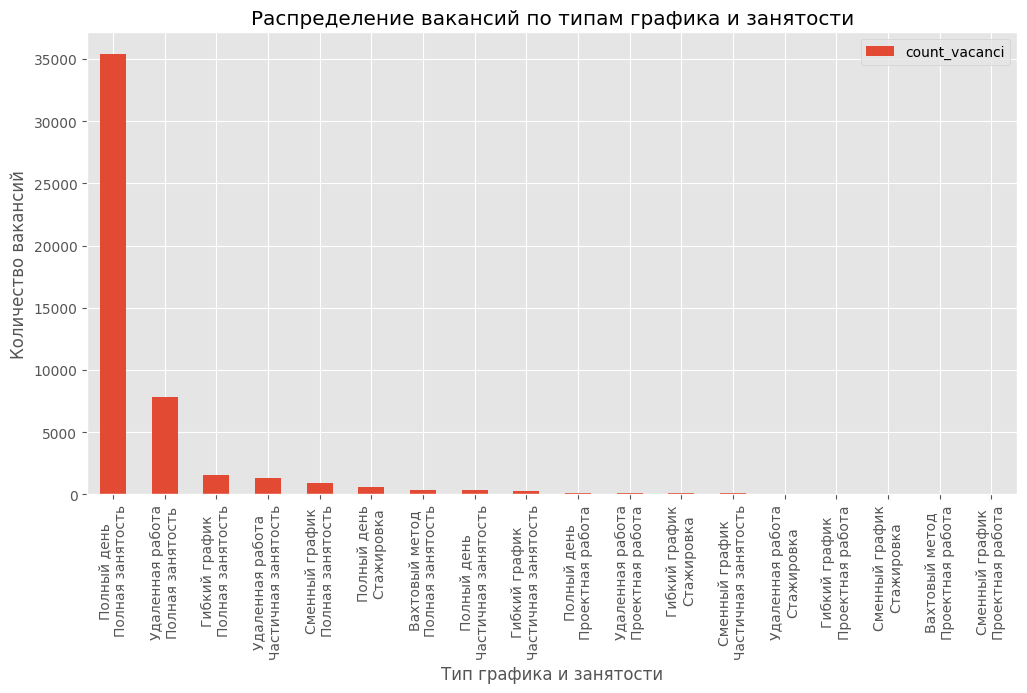

In [196]:
# строка ниже заменит на графике обычное расположение длинных названий на
# на более удобное для восприятия и компановки графика
df_4_4['united'] = df_4_4['type_schedule'] + '\n'+ df_4_4['type_employment']
df_4_4.plot(kind='bar', x='united', y='count_vacanci', figsize=(12, 6), title='Распределение вакансий по типам графика и занятости',
    xlabel='Тип графика и занятости',
    ylabel='Количество вакансий')


5. Напишите запрос, выводящий значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, 
в которых указан данный вариант опыта. 

In [197]:
# текст запроса
query_4_5 = f'''
SELECT
    experience,
    count(*) AS count_vacanci
FROM 
    public.vacancies 
GROUP BY 
    experience
ORDER BY count(*)
'''

In [198]:
# результат запроса
df_4_5 = pd.read_sql_query(query_4_5, connection)
display(df_4_5)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\1393685526.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_4_5 = pd.read_sql_query(query_4_5, connection)


,experience,count_vacanci
0,Более 6 лет,1337
1,Нет опыта,7197
2,От 3 до 6 лет,14511
3,От 1 года до 3 лет,26152


***

Визуализируем полученные результаты

<Axes: title={'center': 'Распределение вакансий по опыту работы'}, xlabel='Опыт работы', ylabel='Количество вакансий'>

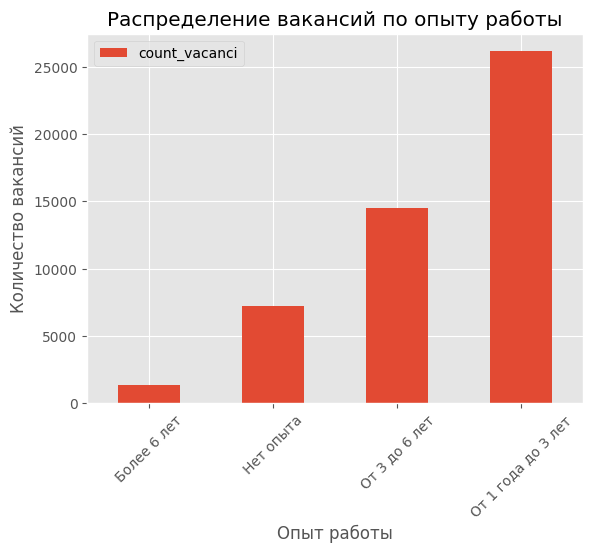

In [199]:
df_4_5.plot(kind='bar', x='experience', y='count_vacanci', rot=45,
    title='Распределение вакансий по опыту работы',
    xlabel='Опыт работы',
    ylabel='Количество вакансий'
    )

#### Выводы по детальному анализу вакансий
В данном разделе анализ проводился по следующим ключевым направлениям: 
* **География рынка:** Определена  пятерка самых экономически активных регионов, причем не только в России. Ими оказались Москва, Санкт-Петербург, Минск, Новосибирск, Алматы. Этот факт подтверждается простой взаимосвязью: чем больше вакансий тем выше экономическая активность.
* **Прозрачность вознаграждения:** Выявлено, что работодатели неохотно указывают предлагаемые размеры заработных плат. Из 49197 вакансий, данные о заработных платах были заполнены только в половине случаев - 24073. Это означает, что работодатели гибко подходят к оплате труда сотрудников и за одну и ту же работу заработная плата может быть разной. С одной стороны работодатели пытаются экономить на выплатах ЗП, с другой, не хотят упускать подвернувшихся, действительно ценных соискателей.
* **Зарплатные ориентиры:** Выяснили чисто статистическую информацию о заработных платах на рынке труда. Среднее значение нижней предлагаемой границы ЗП составляет - 71065 руб. среднее значение верхней границы ЗП составляет - 110537 руб. Эти данные можно использовать соискателям как важный индикатор для сравнения. Чего ты стоишь на рынке труда? Нужно понимать, что рынок труда это своего рода "живой организм". Какие-то профессии являются стагнирующими ("вымирающими"), соответственно ЗП в них ниже рынка, а какие-то растущие и высокотехнологичными - в этих профессиях ЗП обычно выше рынка. Может быть стоит пойти учиться?
* **Тип занятости:** Абсолютным лидером предпочтений, с огромным отрывом от остальных, является тип "Полный день - Полная занятость" - более 35000. Напомню, всего вакансий в базе - 49197 вакансий. Это говорит о том, что на рынке для большинства рабочих мест, критично непосредственное участие сотрудника. Второй по популярности вариант "Удаленная работа - Полная занятость" - 7802 вакансии. Хотя разрыв между первым и вторым вариантом огромен, уже можно отслеживать глобальный тренд на автоматизацию и цифровизацию различных бизнес-процессов.
* **Востребованность опыта:** Интересный вывод можно сделать, получив результаты исследования по уровню опытности специалистов. Самыми востребованными оказались специалисты с опытом От 1 года до 3 лет - более 25000 вакансий. Это «золотая середина» для работодателя: такие сотрудники уже обладают практическими навыками, но при этом максимально адаптивны и стоят дешевле более опытных коллег. Второе место занимают специалисты с опытом от 3 до 6 лет, что указывает на дефицит квалифицированных кадров среднего звена.



# Юнит 5. Анализ работодателей

1. Напишите запрос, который позволит узнать, какие работодатели находятся на первом и пятом месте по количеству вакансий.

In [200]:
# текст запроса
query_5_1 = f'''
SELECT
    e.name AS employer_name,
    count(*) AS count_vacanci
FROM 
    public.employers e
    JOIN public.vacancies v ON e.id = v.employer_id
GROUP BY 
    e.id, e.name
ORDER BY 
    count(*) DESC
LIMIT 20
'''

In [201]:
# результат запроса
df_5_1 = pd.read_sql_query(query_5_1, connection)
display(df_5_1)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\3282492979.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_1 = pd.read_sql_query(query_5_1, connection)


,employer_name,count_vacanci
0,Яндекс,1933
1,Ростелеком,491
2,Тинькофф,444
3,СБЕР,428
4,Газпром нефть,331
5,ИК СИБИНТЕК,327
6,МТС,292
7,DataArt,247
8,Совкомбанк Технологии,204
9,Первый Бит,176


Визуально продемонстрируем доминирование Яндекса над остальными компаниями. Для этого построим столбчатую диаграмму

<Axes: title={'center': 'Распределение вакансий по работодателям'}, xlabel='Топ 20 Работодателей', ylabel='Количество вакансий'>

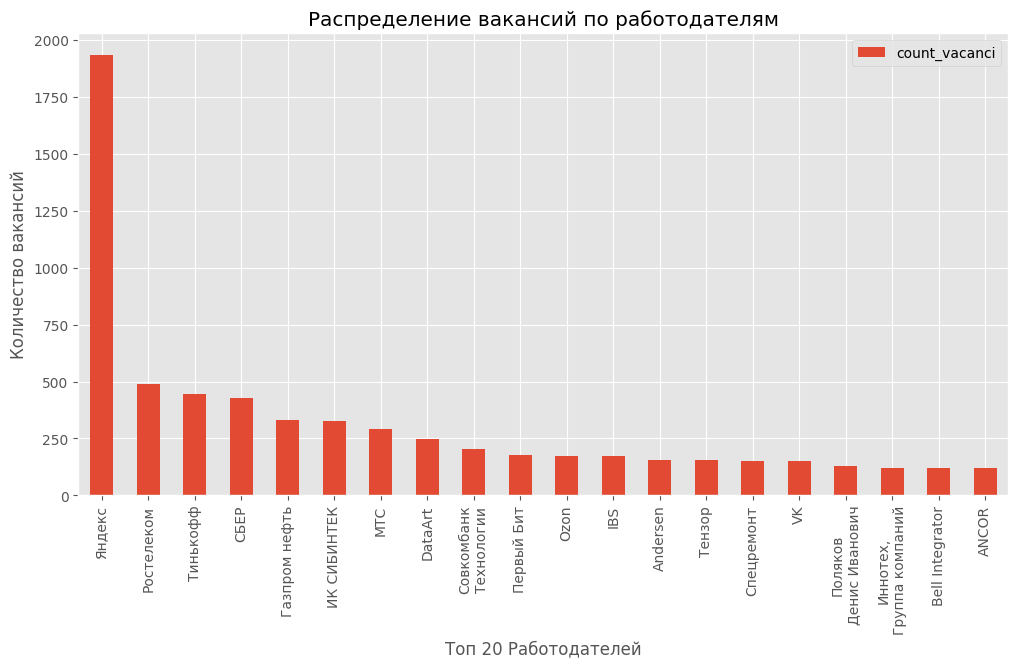

In [202]:
# создадим словарь, который зафиксирует каким образом разместить длинные названия 
# на графике
replacements = {
    'Совкомбанк Технологии': 'Совкомбанк\nТехнологии',
    'Иннотех, Группа компаний': 'Иннотех,\nГруппа компаний',
    'Поляков Денис Иванович': 'Поляков\nДенис Иванович'
}
# строка ниже заменит на графике обычное расположение длинных названий на
# на более удобное для восприятия 
df_5_1['employer_name'] = df_5_1['employer_name'].replace(replacements)  
df_5_1.plot(kind='bar', x='employer_name', y='count_vacanci', rot=90,
    title='Распределение вакансий по работодателям',
    xlabel='Топ 20 Работодателей',
    ylabel='Количество вакансий',
    figsize=(12, 6)
    )

2. Напишите запрос, который для каждого региона выведет количество работодателей и вакансий в нём.
Среди регионов, в которых нет вакансий, найдите тот, в котором наибольшее количество работодателей.


В таблице employers нет явного указания, которая из колонок является ключом для соединения с таблицей areas. Для определения какая колонка - ключ, проведем небольшое исследование. В колонка area данные имеют тип - int4, это значит данные представлены в виде целых чисел, что необходимо для пересчета. Этот факт является первым признаком того, что area - является ключом. Второе проверим совпадает ли колонка e.area c колонкой a.id. Для этого напишем запрос проверающий сходство:   

In [203]:
query_5_2_1 = f'''
SELECT 
    e.area
FROM 
    public.employers e
    LEFT JOIN public.areas a ON e.area = a.id
WHERE 
    a.id IS NULL AND e.area IS NOT NULL
'''

In [204]:
 # результат запроса
df_5_2_1 = pd.read_sql_query(query_5_2_1, connection)
display(df_5_2_1)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\900727152.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_2_1 = pd.read_sql_query(query_5_2_1, connection)


,area


Так как запрос ничего не вернул, это значит что уникальные значения в колонках e.area и a.id одинаковые. Значит можно сделать вывод, что колонка area в таблице employers это ключ для соединения с таблицей areas.

### Данное задание имеет два решения:
* вариант 1. Частный случай, для условия: "Среди регионов в которых нет вакансий"
* вариант 2. Универсальное решение для любых условии задания. Это особенно важно, если в условии отсутствует фраза: "Среди регионов, в которых нет вакансий".
##### Эти два варианте отличаются использованием оператора DISTINCT. В первом варианте использование DISTINCT не обязательно в связи с тем, что у SQL нет необходимости сопоставлять для каждого региона вакансии, так как их по условию задания быть не должно. В этом случае SQL не меняет количество строк. 
#### Во втором варианте SQL начнет копировать "размножать" один и тот же регион под каждую найденную в нем вакансию. В этом случае использование DISTINCT становиться производственной необходимостью, для получения корректных данных.
* Важное отличие в работе двух запросов - это скорость обработки. Второй запрос обрабатывается значительно дольше. Именно поэтому решение этого задание следует разбить на два варианта. 

Ниже я приведу два запроса: первый - для частного случая, второй - универсальный. 

In [205]:
# ПЕРВЫЙ ЗАПРОС - ДЛЯ ЧАСТНОГО СЛУЧАЯ
# текст запроса
query_5_2 = f'''
SELECT 
    a.name AS area_name,
    count(e.id) AS employer_count,
    count(v.id) AS vacancy_count
FROM 
    -- склеиваем между собой три таблицы по схеме "звезда"
    public.areas a   -- базовая таблица, к которой приссоединим две другие
    LEFT JOIN public.employers e ON a.id = e.area
    LEFT JOIN public.vacancies v ON v.area_id = a.id
GROUP BY 
    a.id, a.name
HAVING count(v.id) = 0
ORDER BY 2 DESC
LIMIT 1
'''

In [206]:
# ВТОРОЙ ЗАПРОС - УНИВЕРСАЛЬНЫЙ
# текст запроса
query_5_2_0 = f'''
SELECT 
    a.name AS area_name,
    count(DISTINCT e.id) AS employer_count,
    count(DISTINCT v.id) AS vacancy_count
FROM 
    public.areas a 
    LEFT JOIN public.employers e ON a.id = e.area
    LEFT JOIN public.vacancies v ON v.area_id = a.id
GROUP BY 
    a.id, a.name
HAVING count(DISTINCT v.id) = 0
ORDER BY 2 DESC
LIMIT 1
'''

In [207]:
# результат запроса
df_5_2 = pd.read_sql_query(query_5_2, connection)
display(df_5_2)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\2659449573.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_2 = pd.read_sql_query(query_5_2, connection)


,area_name,employer_count,vacancy_count
0,Россия,410,0


3. Для каждого работодателя посчитайте количество регионов, в которых он публикует свои вакансии. Отсортируйте результат по убыванию количества.


In [208]:
# текст запроса
query_5_3 = f'''
SELECT 
    e.name AS employer_name,
    COUNT(DISTINCT v.area_id) AS area_count
FROM 
    public.employers e
    JOIN public.vacancies v ON e.id = v.employer_id
GROUP BY 
    e.id, e.name 
ORDER BY 2 DESC
LIMIT 20
'''

In [209]:
# результат запроса
df_5_3 = pd.read_sql_query(query_5_3, connection)
display(df_5_3)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\1820345300.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_3 = pd.read_sql_query(query_5_3, connection)


,employer_name,area_count
0,Яндекс,181
1,Ростелеком,152
2,Спецремонт,116
3,Поляков Денис Иванович,88
4,ООО ЕФИН,71
5,Совкомбанк,63
6,МТС,55
7,"ЭФКО, Управляющая компания",49
8,Почта России,48
9,КРОН,48


Построим столбчатую диаграмму, на которой наглядно видно соотношение представленности работодателей в регионах. Для этого покажем на графике Топ 20 работодателей.

<Axes: title={'center': 'Представленность работодателей по регионам'}, xlabel='Топ 20 Работодателей', ylabel='Количество регионов'>

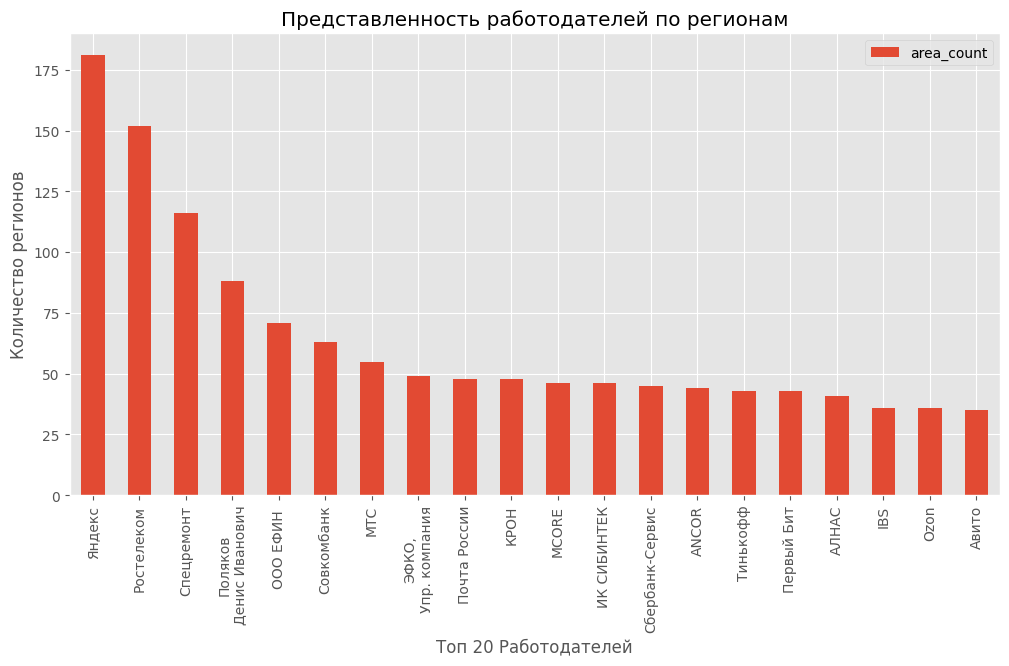

In [210]:
# создадим словарь, который зафиксирует каким образом разместить длинные названия 
# на графике
replacements = {
    'ЭФКО, Управляющая компания': 'ЭФКО,\nУпр. компания',
    'Поляков Денис Иванович': 'Поляков\nДенис Иванович'
}
# строка ниже заменит на графике обычное расположение длинных названий на
# на более удобное для восприятия 
df_5_3['employer_name'] = df_5_3['employer_name'].replace(replacements)
df_5_3.plot(kind='bar', x='employer_name', y='area_count', rot=90,
    title='Представленность работодателей по регионам',
    xlabel='Топ 20 Работодателей',
    ylabel='Количество регионов',
    figsize=(12, 6)
    )

4. Напишите запрос для подсчёта количества работодателей, у которых не указана сфера деятельности. 

In [211]:
# текст запроса
query_5_4 = f'''
SELECT 
    COUNT(*) AS industryless_count
FROM 
    -- для склейки двух нужных нам таблиц используем третью - связующую таблицу
    public.employers e
    LEFT JOIN public.employers_industries ei ON e.id = ei.employer_id
    LEFT JOIN public.industries i ON ei.industry_id = i.id
WHERE i.name IS NULL
'''

In [212]:
# результат запроса
df_5_4 = pd.read_sql_query(query_5_4, connection)
display(df_5_4)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\1129921700.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_4 = pd.read_sql_query(query_5_4, connection)


,industryless_count
0,8419


5. Напишите запрос, чтобы узнать название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности. 

In [245]:
# текст запроса
query_5_5 = f'''
SELECT DISTINCT
    e.name AS employer_name
FROM 
    public.employers e
    LEFT JOIN public.employers_industries ei ON e.id = ei.employer_id
    LEFT JOIN public.industries i ON ei.industry_id = i.id
GROUP BY 
    e.id, e.name
HAVING COUNT(i.id) = 4
ORDER BY 1
OFFSET 2  -- исключаем вывод 2-х самых верхних строк
LIMIT 1   -- выводим одну, самую верхнюю строку (третью в списке)
'''

In [246]:
# результат запроса
df_5_5 = pd.read_sql_query(query_5_5, connection)
display(df_5_5)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\1992736659.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_5 = pd.read_sql_query(query_5_5, connection)


,employer_name
0,2ГИС


6. С помощью запроса выясните, у какого количества работодателей в качестве сферы деятельности указана Разработка программного обеспечения.


In [215]:
# текст запроса
query_5_6 = f'''
SELECT 
    COUNT(*) AS it_employer_count
FROM 
    public.employers e
    JOIN public.employers_industries ei ON e.id = ei.employer_id
    JOIN public.industries i ON ei.industry_id = i.id
WHERE i.name = 'Разработка программного обеспечения'
'''

In [216]:
# результат запроса
df_5_6 = pd.read_sql_query(query_5_6, connection)
display(df_5_6)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\14767730.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_6 = pd.read_sql_query(query_5_6, connection)


,it_employer_count
0,3553


7. Для компании «Яндекс» выведите список регионов-миллионников, в которых представлены вакансии компании, вместе с количеством вакансий в этих регионах. Также добавьте строку Total с общим количеством вакансий компании. Результат отсортируйте по возрастанию количества.

Список городов-милионников надо взять [отсюда](https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8). 

Если возникнут трудности с этим задание посмотрите материалы модуля  PYTHON-17. Как получать данные из веб-источников и API. 

In [ ]:
from urllib.parse import quote_plus
import requests

In [218]:
#!pip install lxml

In [219]:
# код для получения списка городов-милионников

## для сокращенной, красивой ссылки используем quote_plus
url = quote_plus('https://ru.wikipedia.org/wiki/Города-миллионеры_России', safe = ':/')
# обходим защиту википедии, для этого используем библиотеку requests
header = {
  "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
  "(KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36"
}
response = requests.get(url, headers=header)
# данный вариант запроса может извлечь из интернет ресурсов только таблицы
tables = pd.read_html(response.text)
#  выбираем нужную таблицу и трансформируем информацию из нужной колонки в кортеж
city_mill = tables[0]['Город'].values.tolist()  
city_mill = tuple(city_mill)
city_mill # для проверки выводим результат на монитор

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\3728537807.py:12: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


('Москва',
 'Санкт-Петербург',
 'Новосибирск',
 'Екатеринбург',
 'Казань',
 'Красноярск',
 'Нижний Новгород',
 'Челябинск',
 'Уфа',
 'Краснодар',
 'Самара',
 'Ростов-на-Дону',
 'Омск',
 'Воронеж',
 'Пермь',
 'Волгоград')

In [220]:
# текст запроса
query_5_7 = f'''
-- перед выолненим основных условий задания сформируем с помощью WITH виртуальную таблицу
-- в которой будет представллена информация касающаяся только компании Яндекс.
WITH yandex_jobs AS (
    SELECT
        a.name AS area_name,
        v.id AS vacancy_id 
    FROM 
        public.employers e
        JOIN public.vacancies v ON e.id = v.employer_id
        JOIN public.areas a ON v.area_id = a.id
    WHERE
        e.name LIKE 'Яндекс'
    )
-- для выполнеия основных заданий используем виртуальную таблицу, 
-- которая значительно меньше по размеру исходных таблиц.
SELECT 
    area_name,
    COUNT(vacancy_id) AS vacancy_cnt  
FROM
    yandex_jobs
WHERE
    area_name in {city_mill}
GROUP BY
    area_name

-- к результирующей таблице подклеиваем снизу строку 'Total' с общим кол-вом вакансий
UNION ALL
SELECT
    'Total', COUNT(vacancy_id)
FROM
    yandex_jobs
WHERE
    area_name IN {city_mill}
ORDER BY 2 

'''

С помощью столбчатой диаграммы посмотрим распределение вакансий от компании Яндекс

In [221]:
# результат запроса
df_5_7 = pd.read_sql_query(query_5_7, connection)
display(df_5_7)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\796585636.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5_7 = pd.read_sql_query(query_5_7, connection)


,area_name,vacancy_cnt
0,Омск,21
1,Челябинск,22
2,Красноярск,23
3,Волгоград,24
4,Пермь,25
5,Ростов-на-Дону,25
6,Казань,25
7,Уфа,26
8,Самара,26
9,Краснодар,30


***

<Axes: title={'center': 'Распределение вакансий от Яндекс по городам-миллионикам'}, xlabel='Города-миллионики', ylabel='Количество вакансий'>

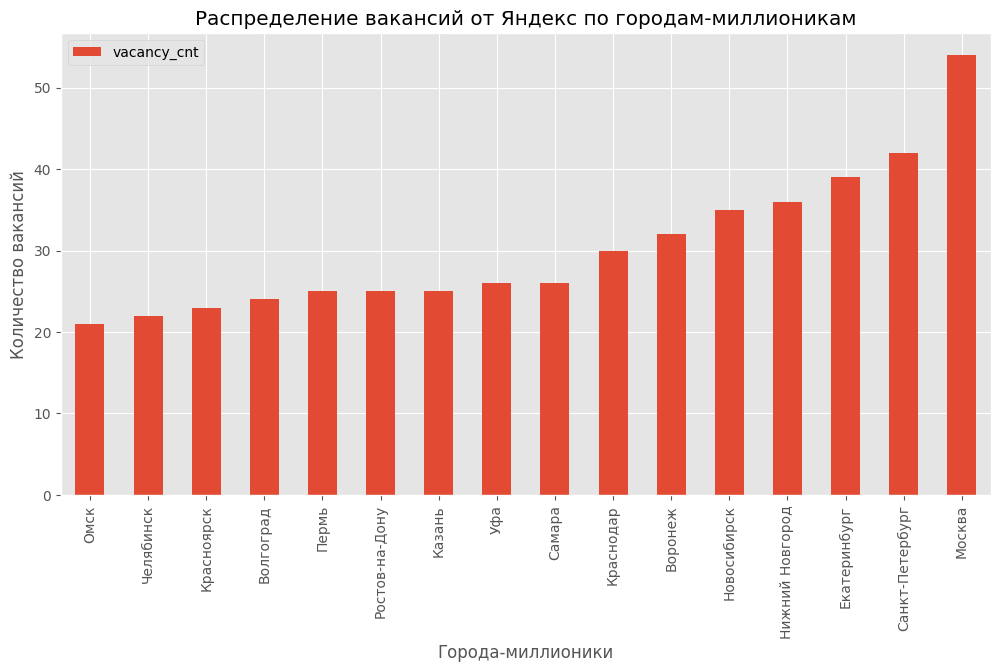

In [222]:
df_5_7[df_5_7['area_name'] != 'Total'].plot(
    kind='bar', x='area_name', y='vacancy_cnt', rot=90,
    title='Распределение вакансий от Яндекс по городам-миллионикам',
    xlabel='Города-миллионики',
    ylabel='Количество вакансий',
    figsize=(12, 6)
    )

#### Выводы по анализу работодателей
В данном разделе анализ проводился по следующим ключевым направлениям:
* **Лидеры рынка:** Определен пятерка предприятий-гигантов, которые доминируют на рынке труда. Абсолютный лидер рынка - Яндекс(1933 вакансии), второе и последующие места делят: Ростелеком(491 вакансия), Тинкофф(444 вакансии), СБЕР(428 вакансий), Газпром нефть(331 вакансия).
* **Федеральные компании:** Анализ регионов без активных вакансий выявил примечательный факт: лидером по количеству зарегистрированных работодателей является Россия (410 компаний). Из этого, я предполагаю, можно сделать следующий вывод: мы определили количестов компаний, которые работают на федеральном уровне, т.е. по всейс стране. 
* **Топ-ы федеральных компаний:** Определены самые крупные компании федерального уровня. Тройка лидеров: Лидер - Компания Яндекс, представлена в 181 регионе, затем компания Ростелеком, представлена в 152 регионах и компания Спецремонт, представлена в 116 регионах. Более развернутую картину по работодателям можно посмотреть на графике 'Представленность работодателей по регионам'.
* **Выявлено** значительное количество работодателей (8 419 компаний), у которых не указана сфера деятельности. Это свидетельствует о том, что значительная часть базы представлена либо многопрофильными компаниями, либо компаниями, предпочитающими сохранять анонимность своей отрасли(Кадровые агенства и посредники). Для анализа это означает необходимость учитывать возможную погрешность при распределении вакансий по отраслям.
* **Многопрофильные компании:** Максимальное число сфер деятельности указанное компаниями - 5. Число компаний, работающих одновременно 5 различных сферах - 1244. Это говорит о том, многопрофильные компании занимаю небольшую долю рынка, порядка 2-5%. Самый главный вывод, который можно сделать - рынок принадлежит узконаправленным компаниям. Что это значит для соискателя? На рынке больше востребованы узкие специалисты, а не специалисты широкого профиля.
* **Анализ сегмента «Разработка программного обеспечения».** Анализ показал высокую концентрацию работодателей в данном сегменте. Несмотря на то, что «Разработка ПО» — это лишь одна из 294 представленных в базе сфер деятельности (менее 0,35% от общего перечня), в ней сосредоточено 15% всех активных работодателей (3 553 из 23 501). Такая значительная диспропорция подтверждает высокий спрос на специалистов по разработке программного обеспечения.
* **Анализ компании Яндекс.** Яндекс является абсолютным лидером по чмслу размещенных вакансий -1933 ваканчии. Детальный анализ распределения спроса выявил интересную закономерность:  Судя по вакансиям размещенным в городах миллиониках можно смело утверждать что компания заинтересована в развитии своего бизнеса в крыпных городах (25% от всех вакансий компании Яндекс). Подавляющее большинство вакансий (75%) распределено за пределами крупнейших городов. Это свидетельствует о стремлении компании к максимальному географическому охвату и контролю локальных рынков (такси, доставка).


# Юнит 6. Предметный анализ

1. Сколько вакансий имеет отношение к данным?

Считаем, что вакансия имеет отношение к данным, если в её названии содержатся слова 'data' или 'данн'.

*Подсказка: Обратите внимание, что названия вакансий могут быть написаны в любом регистре.* 


In [223]:
# текст запроса
query_6_1 = f'''
SELECT 
    COUNT(*)
FROM 
    public.vacancies
WHERE 
    lower(name) LIKE '%data%' OR lower(name) LIKE '%данн%'
'''

In [224]:
# результат запроса 
df_6_1 = pd.read_sql_query(query_6_1, connection)
display(df_6_1)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\1295305549.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_1 = pd.read_sql_query(query_6_1, connection)


,count
0,1771


2. Сколько есть подходящих вакансий для начинающего дата-сайентиста? 
Будем считать вакансиями для дата-сайентистов такие, в названии которых есть хотя бы одно из следующих сочетаний:
* 'data scientist'
* 'data science'
* 'исследователь данных'
* 'ML' (здесь не нужно брать вакансии по HTML)
* 'machine learning'
* 'машинн%обучен%'

** В следующих заданиях мы продолжим работать с вакансиями по этому условию.*

Считаем вакансиями для специалистов уровня Junior следующие:
* в названии есть слово 'junior' *или*
* требуемый опыт — Нет опыта *или*
* тип трудоустройства — Стажировка.
 

In [225]:
# текст запроса
query_6_2 = f'''
SELECT 
    COUNT(*)
FROM 
    public.vacancies
WHERE
    (lower(name) LIKE '%data scientist%' OR
    lower(name) LIKE '%data science%' OR
    lower(name) LIKE '%исследователь данных%' OR
    -- Важно! ML может быть записана и строчными буквами, поэтому применяем ILIKE 
    (name ILIKE '%ML%' AND name NOT ILIKE '%HTML%') OR
    lower(name) LIKE '%machine learning%' OR
    lower(name) LIKE '%машинн%обучен%')
    AND
    (lower(name) LIKE '%junior%' OR
    experience = 'Нет опыта' OR 
    employment = 'Стажировка')
'''

In [226]:
# результат запроса
df_6_2 = pd.read_sql_query(query_6_2, connection)
display(df_6_2)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\265335090.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_2 = pd.read_sql_query(query_6_2, connection)


,count
0,51


3. Сколько есть вакансий для DS, в которых в качестве ключевого навыка указан SQL или postgres?

** Критерии для отнесения вакансии к DS указаны в предыдущем задании.*

In [227]:
# текст запроса
query_6_3 = f'''
SELECT 
    COUNT(*)
FROM 
    public.vacancies
WHERE 
    (
    lower(name) LIKE '%data scientist%' OR
    lower(name) LIKE '%data science%' OR
    lower(name) LIKE '%исследователь данных%' OR
    -- Важно! ML может быть записана и строчными буквами, поэтому применяем ILIKE
    (name ILIKE '%ML%' AND name NOT ILIKE '%HTML%') OR
    lower(name) LIKE '%machine learning%' OR
    lower(name) LIKE '%машинн%обучен%'
    )
    AND 
    (upper(key_skills) LIKE '%SQL%' OR lower(key_skills) LIKE '%postgres%') 
   
'''

In [228]:
# результат запроса
df_6_3 = pd.read_sql_query(query_6_3, connection)
display(df_6_3)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\2681858932.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_3 = pd.read_sql_query(query_6_3, connection)


,count
0,229


4. Проверьте, насколько популярен Python в требованиях работодателей к DS.Для этого вычислите количество вакансий, в которых в качестве ключевого навыка указан Python.

** Это можно сделать помощью запроса, аналогичного предыдущему.*

In [229]:
# текст запроса
query_6_4 = f'''
SELECT 
    COUNT(*)
FROM 
    public.vacancies
WHERE 
    (
    lower(name) LIKE '%data scientist%' OR
    lower(name) LIKE '%data science%' OR
    lower(name) LIKE '%исследователь данных%' OR
    (name ILIKE '%ML%' AND name NOT ILIKE '%HTML%') OR
    lower(name) LIKE '%machine learning%' OR
    lower(name) LIKE '%машинн%обучен%'
    )
    AND lower(key_skills) LIKE '%python%' 
   
'''

In [230]:
# результат запроса
df_6_4 = pd.read_sql_query(query_6_4, connection)
display(df_6_4)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\566482907.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_4 = pd.read_sql_query(query_6_4, connection)


,count
0,357


5. Сколько ключевых навыков в среднем указывают в вакансиях для DS?
Ответ округлите до двух знаков после точки-разделителя.

In [231]:
# текст запроса
query_6_5 = f'''
SELECT
    ROUND(
        AVG(
            array_length(string_to_array(key_skills, E'\t'), 1)), 
        2
        ) AS skills_count
FROM 
    public.vacancies
WHERE 
    (lower(name) LIKE '%data scientist%' OR
    lower(name) LIKE '%data science%' OR
    lower(name) LIKE '%исследователь данных%' OR
    (name LIKE '%ML%' AND name NOT ILIKE '%HTML%') OR
    lower(name) LIKE '%machine learning%' OR
    lower(name) LIKE '%машинн%обучен%'
    )  
'''

In [232]:
# результат запроса
df_6_5 = pd.read_sql_query(query_6_5, connection)
display(df_6_5)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\3931282954.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_5 = pd.read_sql_query(query_6_5, connection)


,skills_count
0,6.41


6. Напишите запрос, позволяющий вычислить, какую зарплату для DS в **среднем** указывают для каждого типа требуемого опыта (уникальное значение из поля *experience*). 

При решении задачи примите во внимание следующее:
1. Рассматриваем только вакансии, у которых заполнено хотя бы одно из двух полей с зарплатой.
2. Если заполнены оба поля с зарплатой, то считаем зарплату по каждой вакансии как сумму двух полей, делённую на 2. Если заполнено только одно из полей, то его и считаем зарплатой по вакансии.
3. Если в расчётах участвует null, в результате он тоже даст null (посмотрите, что возвращает запрос select 1 + null). Чтобы избежать этой ситуацию, мы воспользуемся функцией [coalesce](https://postgrespro.ru/docs/postgresql/9.5/functions-conditional#functions-coalesce-nvl-ifnull), которая заменит null на значение, которое мы передадим. Например, посмотрите, что возвращает запрос `select 1 + coalesce(null, 0)`

Выясните, на какую зарплату в среднем может рассчитывать дата-сайентист с опытом работы от 3 до 6 лет. Результат округлите до целого числа. 

In [233]:
# текст запроса
query_6_6 = f'''
SELECT
    experience AS experience_applicant,
    -- запись ниже одновременно проверят все три условия, связанные с заполнением
    -- ячеек в колонках salary_from и salary_to
    ROUND(
        AVG(COALESCE(salary_from, salary_to) + COALESCE(salary_to, salary_from)) / 2
        ) AS avg_salary
FROM 
    public.vacancies
WHERE 
    (lower(name) LIKE '%data scientist%' OR
    lower(name) LIKE '%data science%' OR
    lower(name) LIKE '%исследователь данных%' OR
    (name LIKE '%ML%' AND name NOT ILIKE '%HTML%') OR
    lower(name) LIKE '%machine learning%' OR
    lower(name) LIKE '%машинн%обучен%'
    )
    AND
    -- исключаем из таблицы строки в которых не заполнены ячейки в двух колонках
    -- salary_from и salary_to одновременно 
    (salary_from IS NOT NULL OR salary_to IS NOT NULL)
GROUP BY
    experience
'''

In [234]:
# результат запроса
df_6_6 = pd.read_sql_query(query_6_6, connection)
display(df_6_6)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\3037240071.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_6 = pd.read_sql_query(query_6_6, connection)


,experience_applicant,avg_salary
0,Нет опыта,74643.0
1,От 1 года до 3 лет,139675.0
2,От 3 до 6 лет,243115.0


***

#### Выводы по предметному анализу
* Специалисты по Data Science составляют 3,6% от общего объема рынка (1 771 из 49 197 вакансий). Это подтверждает, что DS остается узкоспециализированным и направлением. Массовому рынку по-прежнему чаще требуются линейные сотрудники, чем исследователи данных.
* Для начинающих специалистов (без опыта) открыта всего 51 вакансия. Это менее 3% от всех вакансий в сфере Data Science (51 из 1 771). Вывод: устроится на работу по специальности DS крайне сложно. Рынок практически не готов нанимать  новичков, предпочитая специалистов с уже имеющимся практическим опытом. Данный показатель показывает, что конкуренция среди новичков будет огромной.
* Каждая восьмая вакансия в сфере DS (13%) напрямую требует владения SQL или PostgreSQL (229 из 1 771). Вывод: Знание баз данных является обязательным техническим навыком для значительной части специалистов. Работа дата-сайентиста должна начинаться с умения самостоятельно извлечь данные и работать с ними.
* Владение Python требуется в каждой пятой вакансии для DS (20%). Это делает его самым востребованным языком программирования в сегменте. Вывод: Python является важным hard skill-ом для входа в эту специальность. Он встречается в требованиях в 1,5 раза чаще, чем SQL, что подтверждает его статус основного инструмента для анализа данных и построения моделей.
* В среднем работодатели указывают 6.41 ключевого навыка в одной вакансии для Data Science. Вывод: специалист DS должен освоить и уметь использовать большой набор hard skill-ов в отличии от большинства других специалистов. Работодателю недостаточно иметь специалистов владеющих одним инструментом (например, только Python); он(работодатель) ожидает от кандидата целого набора компетенций — от математической статистики до навыков программирования и работы с базами данных.
* В сфере DS наблюдается стремительный рост дохода по мере приобретения опыта. Переход из категории «junior» в категорию «специалист 3–6 лет» увеличивает среднюю зарплату более чем в 3,2 раза (с 75т.р до 243т.р). Вывод: Опыт в Data Science ценится чрезвычайно высоко. Основной финансовый рывок происходит после преодоления трехлетнего рубежа, когда специалист переходит на уровень Senior/Middle+ и его доход становится сопоставим с топ-менеджментом в других отраслях.



# Общий вывод по проекту
### Проведенный анализ подтверждает, что современный рынок труда находится в стадии глубокой цифровой трансформации.
#### Ключевые итоги исследования:
* **1. IT:** Сфера разработки ПО и Data Science являются главными драйверами рынка. Несмотря на то, что это узкие сегменты (DS составляет всего 3.6% вакансий), они задают самые высокие стандарты оплаты труда.
* **2. География возможностей:** Экономическая активность жестко привязана к крупным агломерациям (Москва, Санкт-Петербург), которые выступают финансовыми и технологическими хабами. Лидерство компании «Яндекс» подтверждает стратегию захвата регионов при сохранении интеллектуального центра в мегаполисах.
* **3. Ценность опыта:** Исследование выявило колоссальный разрыв в доходах в зависимости от стажа. Самые эффективные «карьерные лифты» обнаружены в Консалтинге и Data Science, где за 3–6 лет доход специалиста вырастает в 3–4 раза.
* **4. Порог входа:** Для новичков (Junior) рынок остается сложным. Всего 51 вакансия для начинающих DS при среднем требовании в 6.4 ключевых навыка говорит о том, что работодатель ищет «готовых» экспертов.
####  Заключение: Рынок труда неоднороден. В то время как массовые сектора (Розница, Связь) демонстрируют стабильность с низким потолком роста, интеллектуальные и технологические сферы предлагают стремительный рост дохода. Для успешной карьеры в современных условиях критически важны навыки работы с данными (SQL, Python) и готовность к непрерывному обучению.

==================================================================================================

### Проведем дополнительные исследования
Так как вакансии связанные с IT-сферой, мы исследовали в основной части проекта, я займусь исследованием вакансий, не относящихся к IT напрямую или связанных с ними лишь косвенно.

Меня интересуют не конкретные специальности, а сферы деятельности (industries), отраслевые потребности в кадрах и медианный уровень заработных плат и другие показатели. Чтобы не перегружать проект я представлю результаты двух исследований. 

Вначале я определю перечень отраслей связанных с IT-сферой чтобы исключить их из выборки. Затем я проанализирую топ-10 оставшихся отраслей с наибольшим количеством вакансий.

In [235]:
# текст запроса
query_6_7 = f'''
SELECT
    COALESCE(i.name, 'Индустрия не указана') AS industry_name,
    COUNT(DISTINCT v.id) AS industry_vacancy_cnt 
FROM 
    public.employers e
    JOIN public.vacancies v ON e.id = v.employer_id
    LEFT JOIN public.employers_industries ei ON e.id = ei.employer_id
    LEFT JOIN public.industries i ON ei.industry_id = i.id
GROUP BY
    i.id, i.name
ORDER BY 2 DESC
LIMIT 20
'''

In [236]:
# результат запроса
df_6_7 = pd.read_sql_query(query_6_7, connection)
display(df_6_7)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\718282358.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_7 = pd.read_sql_query(query_6_7, connection)


,industry_name,industry_vacancy_cnt
0,Разработка программного обеспечения,12499
1,"Системная интеграция, автоматизации технологи...",11034
2,Индустрия не указана,10084
3,"Интернет-компания (поисковики, платежные систе...",6413
4,Банк,2742
5,Мобильная связь,1585
6,Кадровые агентства,1143
7,Консалтинговые услуги,1137
8,Интернет-провайдер,1095
9,Розничная сеть (продуктовая),1034


Для лучшей визуализвции построим график

<Axes: title={'center': 'Распределение вакансий по сферам деятельности'}, xlabel='Топ 20 сфер деятельности', ylabel='Количество вакансий'>

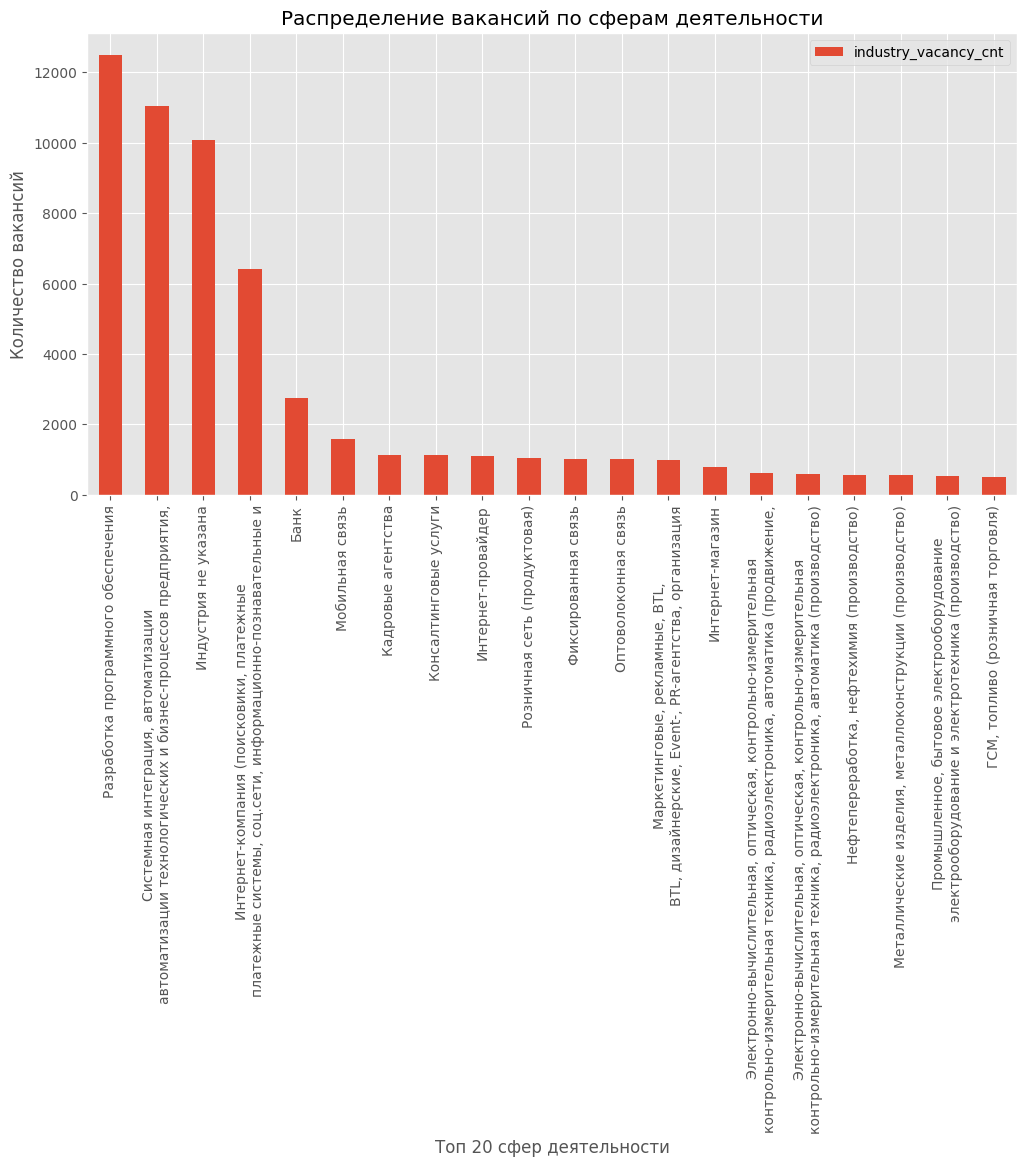

In [237]:
df_6_7['industry_name1'] = df_6_7['industry_name'].apply(lambda x: ' '.join(x.split()[:3]) + '\n' + ' '.join(x.split()[2:7]) if len(x.split())>4 else x)
df_6_7.plot(kind='bar', x='industry_name1', y='industry_vacancy_cnt', rot=90,
    title='Распределение вакансий по сферам деятельности',
    xlabel='Топ 20 сфер деятельности',
    ylabel='Количество вакансий',
    figsize=(12, 6)
    )

На графике сразу видна десятка лучших отраслей, без учета IT-сферы.

Теперь создадим базу для дальнейших исследований с нужной выборкой по отрослям.

In [238]:
# Нужная нам выборка топ-10 отрослей
lst_top10 = df_6_7['industry_name'].iloc[4:14].values.tolist()
lst_top10 = tuple(lst_top10)
lst_top10  # выводим на монитор для проверки

('Банк',
 'Мобильная связь',
 'Кадровые агентства',
 'Консалтинговые услуги',
 'Интернет-провайдер',
 'Розничная сеть (продуктовая)',
 'Фиксированная связь',
 'Оптоволоконная связь',
 'Маркетинговые, рекламные, BTL, дизайнерские, Event-, PR-агентства, организация выставок',
 'Интернет-магазин')

In [239]:
# Запрос, который создает базу для исследований
# текст запроса
query_6_8 = f'''
WITH stats AS (
    SELECT
        i.name AS industry_name,    
        -- замена Более на Свыше для удобства сортировки (по ASC или DESC)
        REPLACE(v.experience, 'Более 6 лет', 'Свыше 6 лет') AS experience_applicant,
        COUNT(DISTINCT v.id) AS vacancy_cnt, -- исключаем повторы
        
        -- находим среднюю ЗП по отрасли в зависимости от опыта работы
        AVG((COALESCE(salary_from, salary_to) + COALESCE(salary_to, salary_from)) / 2) AS avg_s,
        
        -- находим медианную ЗП по отрасли в зависимости от опыта работы       
        PERCENTILE_CONT(0.5) WITHIN GROUP (
            ORDER BY (COALESCE(salary_from, salary_to) + COALESCE(salary_to, salary_from)) / 2
            )::numeric AS median_s
    FROM 
        public.employers e
        JOIN public.vacancies v ON e.id = v.employer_id
        JOIN public.employers_industries ei ON e.id = ei.employer_id
        JOIN public.industries i ON ei.industry_id = i.id 
    WHERE
        i.name IN {lst_top10} -- отфильтровываем топ-10 отраслей  
    GROUP BY
        i.id, i.name, v.experience)
SELECT
    industry_name,
    experience_applicant,
    vacancy_cnt,
    ROUND(avg_s) AS avg_salary,
    ROUND(median_s) AS median_salary,
    -- это коэффициент асимметрии. Отклонение средней зарплаты от медианной в %
    ROUND((avg_s - median_s) / median_s * 100, 2) AS asymmetry_coef
FROM 
    stats
ORDER BY 1, 2 DESC
   
'''

In [240]:
# результат запроса
df_6_8 = pd.read_sql_query(query_6_8, connection)
display(df_6_8)

C:\Users\Николай\AppData\Local\Temp\ipykernel_15348\2103528832.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_6_8 = pd.read_sql_query(query_6_8, connection)


,industry_name,experience_applicant,vacancy_cnt,avg_salary,median_salary,asymmetry_coef
0,Банк,Свыше 6 лет,40,156886.0,127356.0,23.19
1,Банк,От 3 до 6 лет,834,153075.0,116897.0,30.95
2,Банк,От 1 года до 3 лет,1677,75438.0,58000.0,30.07
3,Банк,Нет опыта,191,48417.0,42500.0,13.92
4,Интернет-магазин,Свыше 6 лет,16,99705.0,70000.0,42.44
5,Интернет-магазин,От 3 до 6 лет,212,145022.0,135000.0,7.42
6,Интернет-магазин,От 1 года до 3 лет,484,77911.0,65000.0,19.86
7,Интернет-магазин,Нет опыта,76,46503.0,40000.0,16.26
8,Интернет-провайдер,Свыше 6 лет,9,300000.0,300000.0,0.00
9,Интернет-провайдер,От 3 до 6 лет,184,137784.0,111000.0,24.13


Для удобства восприятия информации переложим результат запроса на график

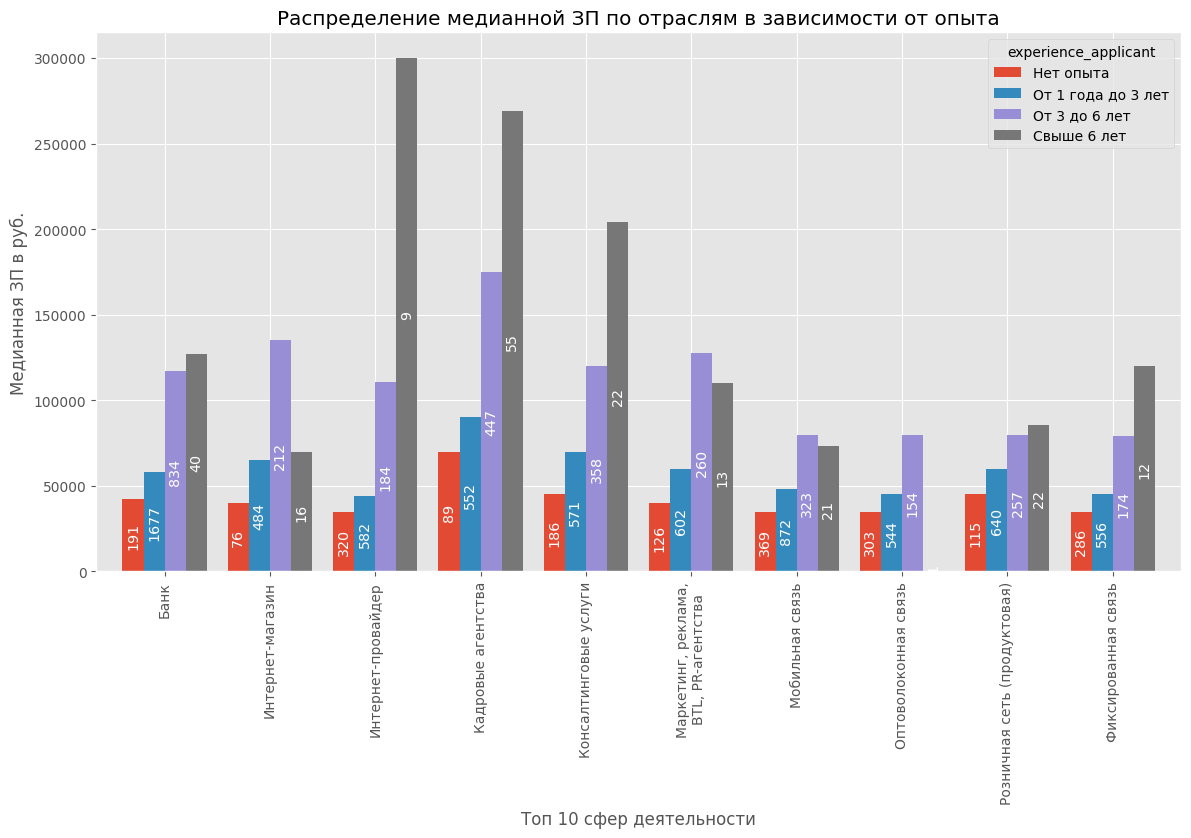

In [241]:
# Заменим длинное название одной отрасли на более короткое, для презентабельности графика
df_6_8['industry_name'] = df_6_8['industry_name'].replace(
    'Маркетинговые, рекламные, BTL, дизайнерские, Event-, PR-агентства, организация выставок', 
    'Маркетинг, реклама,\nBTL, PR-агентства'
    )
plot_data = df_6_8.pivot(
    index='industry_name', columns='experience_applicant', values='median_salary'
    )
count_data = df_6_8.pivot(
    index='industry_name', columns='experience_applicant', values='vacancy_cnt'
    )
# Строим график 
ax = plot_data.plot(
        kind='bar', 
        title='Распределение медианной ЗП по отраслям в зависимости от опыта',
        xlabel='Топ 10 сфер деятельности',
        ylabel='Медианная ЗП в руб.',
        rot=90,
        figsize=(14, 7), width=0.8)

# Запускаем цикл с "наклейкой" количества вакансий
for i, container in enumerate(ax.containers):
    # Берем i-й столбец из count_data (соответствующий цвету столбика)
    labels = count_data.iloc[:, i].fillna(0).astype(int) 
    ax.bar_label(
        container, labels=labels, rotation=90, 
        label_type='center', color='white', fontsize=10.3
        )
plt.show()

* Внутри столбиков указано количество вакансий, соответствующих данной категории 

Теперь перед нами все данные как на ладони. 
### Переходим к исследованиям.

Давайте определим в какой сфере самый эффективный финансовый взлет. Мы оценим, в каких сферах наблюдается самый интенсивный рост медианной заработной платы для специалистов без опыта. При условии что начальная база заработных плат для специалистов без опыта во всех отраслях примерно одинаковая. Стоит отметить, что сфера "Кадровые агентства" демонстрирует аномально высокий старт для новичков (медиана 70 000 руб.), поэтому их нужно исключить из выборки, либо относится к данным по ним с большой осторожностью.  

<Axes: title={'center': 'Коэффициент роста ЗП (Профи vs Новичок)'}, xlabel='Во сколько раз вырастает доход', ylabel='industry_name'>

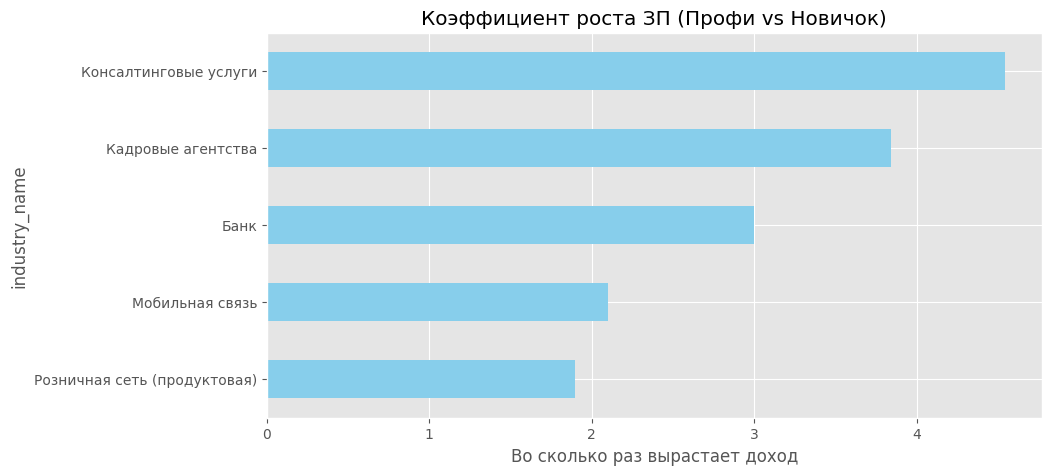

In [242]:
min_val = 20
mask = df_6_8['vacancy_cnt'] >= min_val
df_filt = df_6_8[mask]
plot_data = df_filt.pivot(
    index='industry_name', 
    columns='experience_applicant', 
    values='median_salary'
)
growth_rate = (plot_data['Свыше 6 лет'] / plot_data['Нет опыта']).dropna().sort_values()

# Строим мини-график
growth_rate.plot(
    kind='barh', 
    figsize=(10, 5), 
    color='skyblue',
    title='Коэффициент роста ЗП (Профи vs Новичок)',
    xlabel='Во сколько раз вырастает доход'
)

#### Выводы:
По результатам исследования я бы выделил две сферы в которых самый короткий путь к финансовой независимости: 
* Лидер рынка - Консалтнговые услуги. Данная сфера демонстрирует самый мощный рост ЗП: заработная плата опытного специалиста (6+ лет) более чем в 4.5 раза превышает стартовый уровень. Это свидетельствует о высокой прибавленной стоимости экспертных знаний в консалтинге.
* Вторая сфера - Банки. Здесь наблюдается стабильная и высокая динамика: доход опытного сотрудника увеличивается в 3 раза относительно новичка.

Дополнительное наблюдение:

Наименее эффективной с точки зрения долгосрочного роста доходов оказалась продуктовая розничная сеть. Прирост заработной платы здесь составляет менее 2 раз (коэффициент ~1.8). Это говорит о том что стаж не является ключевым навыком увеличивающим заработную плату.

------------------------------------------------------------------------

### Следующее исследование касается перкоса средней зарплаты относительно медианной.

<Axes: title={'center': 'Перекосы средней ЗП относительно медианной в отраслях'}, xlabel='Топ 10 сфер деятельности', ylabel='Коэффициент асимметрии в %'>

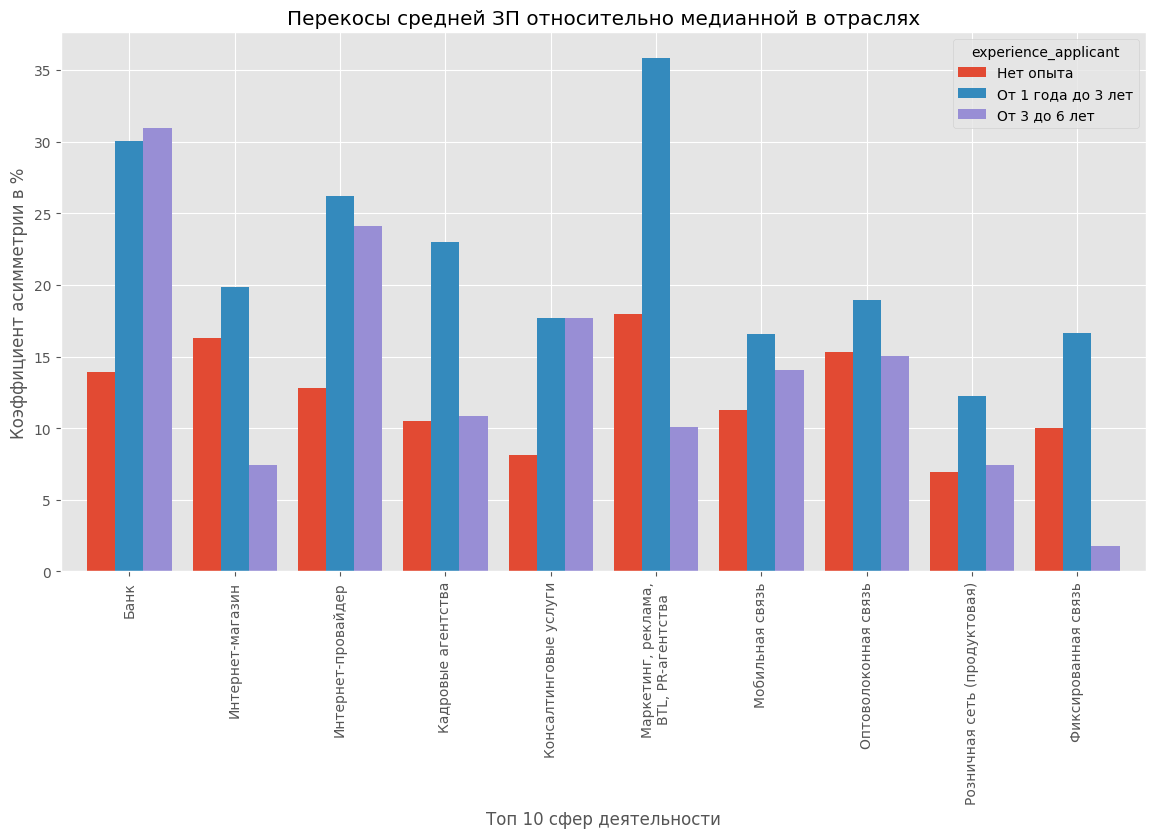

In [ ]:
# убираем значения с выборкой менее 20 вакансий
min_val = 20
mask = df_6_8['vacancy_cnt'] >= min_val
df_filtr = df_6_8[mask]
data = df_filtr.pivot(
    index='industry_name', columns='experience_applicant', values='asymmetry_coef'
    )
# удаляем колонку с обытом более 6 лет, в ней остается слишком мало информации
plot_df = data.drop(['Свыше 6 лет'], axis=1) 
plot_df.plot(
        kind='bar', 
        title='Перекосы средней ЗП относительно медианной в отраслях',
        xlabel='Топ 10 сфер деятельности',
        ylabel='Коэффициент асимметрии в %',
        rot=90,
        figsize=(14, 7), width=0.8)

In [258]:
# подсказка, на что обратить внимание
asymmetry_spread = (plot_df['От 3 до 6 лет'] - plot_df['Нет опыта']).sort_values(ascending=False)
print("Топ отраслей по нарастанию рыночного перегрева:")
print(asymmetry_spread.dropna().head(5))

Топ отраслей по нарастанию рыночного перегрева:
industry_name
Банк                            17.03
Интернет-провайдер              11.32
Консалтинговые услуги            9.57
Мобильная связь                  2.77
Розничная сеть (продуктовая)     0.51
dtype: float64


### Вывод:
Сравнение динамики зарплат и асимметрии позволяет разделить отрасли на три типа:
* **Зоны «сверхдоходов» (Банки, Маркетинг):** Здесь наблюдается самый резкий рост асимметрии (до +17%). Это означает, что к 3–6 годам стажа рынок «взрывается»: большинство получает норму, но за топ-специалистов компании бьются, предлагая зарплаты значительно выше средних.

* **Эффективный лифт (Консалтинг):** Самый выгодный сектор. Зарплата растет в 4.5 раза, при этом высокая асимметрия сохраняется на всех этапах. Это сфера с самым стабильным и высоким финансовым ростом.

* **Стабильный конвейер (Розница, Связь):** Асимметрия близка к 0%. Это «прозрачные» рынки с жесткой тарифной сеткой. Зарплаты предсказуемы,  «пробить потолок» и получить выплату в разы выше медианы здесь практически невозможно.

* **Главный инсайт:** В Маркетинге борьба за таланты начинается на старте (1–3 года), а в Банках — только на этапе зрелости (от 4 и более лет).